In [9]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation

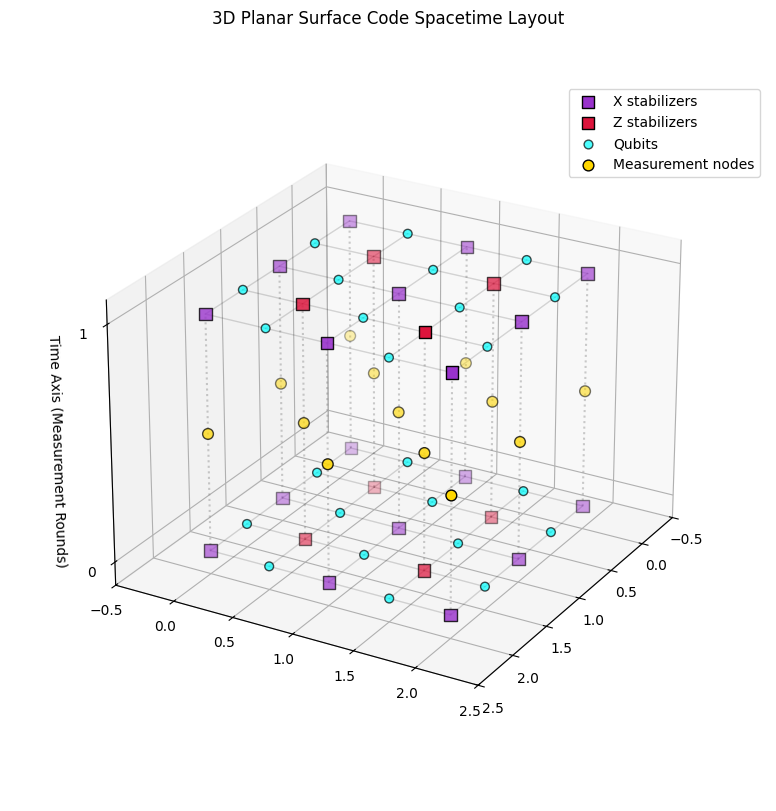

In [10]:
#toric boundry things
def build_midpoint_3d_surface(d, T):
    """
    makes the surface code diagram in the xz plane - so that time is up and down
    """
    star_stabs, plaq_stabs, qubits = [], [], []
    measurements = []
    spatial_edges = []

    for t in range(T):
        #x stab nodes
        for x in range(d):
            for y in range(d):
                star_stabs.append((x, y, t))
                
                if t < T - 1:
                    measurements.append((x, y, t + 0.5))

        #qubit connections
        for x in range(d - 1):
            for y in range(d):
                qubits.append((x + 0.5, y, t))
                spatial_edges.append(((x, y, t), (x + 0.5, y, t)))
                spatial_edges.append(((x + 0.5, y, t), (x + 1, y, t)))
        for x in range(d):
            for y in range(d - 1):
                qubits.append((x, y + 0.5, t))
                spatial_edges.append(((x, y, t), (x, y + 0.5, t)))
                spatial_edges.append(((x, y + 0.5, t), (x, y + 1, t)))

        # z stab and qubit connections
        for x in range(d - 1):
            for y in range(d - 1):
                plaq_center = (x + 0.5, y + 0.5, t)
                plaq_stabs.append(plaq_center)
                if t < T - 1:
                    measurements.append((x + 0.5, y + 0.5, t + 0.5))
                spatial_edges.append((plaq_center, (x + 0.5, y, t)))          
                spatial_edges.append((plaq_center, (x, y + 0.5, t)))          
                spatial_edges.append((plaq_center, (x + 0.5, y + 1, t)))      
                spatial_edges.append((plaq_center, (x + 1, y + 0.5, t)))     

    return star_stabs, plaq_stabs, qubits, measurements, spatial_edges

def visualize_midpoint_3d_surface(d, T):
    fig = plt.figure(figsize=(10, 8), layout='constrained')
    ax = fig.add_subplot(111, projection='3d')
    
    stars, plaqs, qubits, measurements, edges = build_midpoint_3d_surface(d, T)

    #surface code connections
    for p1, p2 in edges:
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], [p1[2], p2[2]], color='black', alpha=0.15, lw=1)

    #time lines
    base_nodes = set([(p[0], p[1]) for p in stars + plaqs])
    for x, y in base_nodes:
        ax.plot([x, x], [y, y], [0, T-1], color='gray', linestyle=':', alpha=0.4, zorder=1)

    # stabilisers
    xs, ys, zs = zip(*stars)
    ax.scatter(xs, ys, zs, c='darkorchid', marker='s', s=80, edgecolors='black', label='X stabilizers ', zorder=5)
    
    xs, ys, zs = zip(*plaqs)
    ax.scatter(xs, ys, zs, c='crimson', marker='s', s=80, edgecolors='black', label='Z stabilizers ', zorder=5)
    
    # qubit nodes
    xs, ys, zs = zip(*qubits)
    ax.scatter(xs, ys, zs, c='#5F9EA0', marker='o', s=40, alpha=0.7, edgecolors='black', label='Qubits', zorder=4)

    # meas nodes at midpoint of rounds
    if measurements:
        xs, ys, zs = zip(*measurements)
        ax.scatter(xs, ys, zs, c='gold', marker='o', s=60, edgecolors='black', label='Measurement nodes', zorder=6)

    ax.set_zlabel('Time Axis (Measurement Rounds)', labelpad=5)
    ax.set_box_aspect(aspect=None, zoom=0.85)

    ax.set_title('3D Planar Surface Code Spacetime Layout', pad=15)
    ax.set_xlim(-0.5, d - 0.5)
    ax.set_ylim(-0.5, d - 0.5)
    ax.set_zlim(-0.1, T - 0.9)
    ax.set_zticks(range(T))

    ax.legend(loc='upper right', bbox_to_anchor=(1, 0.95))
    ax.view_init(elev=25, azim=30)
    
    plt.show()

visualize_midpoint_3d_surface(d=3, T=2) #can change for diff distances and measurement rounds

In [11]:
def build_adaptive_gkp_surface(d, sigma=0.1, max_allowed_rounds=10):
    """Generates surface code layers dynamically based on GKP noise threshold."""
    star_stabs, plaq_stabs, qubits = [], [], []
    trusted_measurements, failed_measurements, spatial_edges = [], [], []
    GKP_THRESHOLD = np.sqrt(np.pi) / 2.0
    t = 0
    keep_going = True
    
    while keep_going and t < max_allowed_rounds:
        # Layer t structural nodes
        for x in range(d):
            for y in range(d):
                star_stabs.append((x, y, t))
        for x in range(d - 1):
            for y in range(d):
                qubits.append((x + 0.5, y, t))
                spatial_edges.append(((x, y, t), (x + 0.5, y, t)))
                spatial_edges.append(((x + 0.5, y, t), (x + 1, y, t)))
        for x in range(d):
            for y in range(d - 1):
                qubits.append((x, y + 0.5, t))
                spatial_edges.append(((x, y, t), (x, y + 0.5, t)))
                spatial_edges.append(((x, y + 0.5, t), (x, y + 1, t)))
        for x in range(d - 1):
            for y in range(d - 1):
                plaq_center = (x + 0.5, y + 0.5, t)
                plaq_stabs.append(plaq_center)
                spatial_edges.append((plaq_center, (x + 0.5, y, t)))
                spatial_edges.append((plaq_center, (x, y + 0.5, t)))
                spatial_edges.append((plaq_center, (x + 0.5, y + 1, t)))
                spatial_edges.append((plaq_center, (x + 1, y + 0.5, t)))

        # Midpoint measurements (t + 0.5)
        any_errors_this_round = False
        for x in range(d):
            for y in range(d):
                noise = np.random.normal(0, sigma)
                if abs(noise) > GKP_THRESHOLD:
                    failed_measurements.append((x, y, t + 0.5))
                    any_errors_this_round = True
                else:
                    trusted_measurements.append((x, y, t + 0.5))
                    
        for x in range(d - 1):
            for y in range(d - 1):
                noise = np.random.normal(0, sigma)
                if abs(noise) > GKP_THRESHOLD:
                    failed_measurements.append((x + 0.5, y + 0.5, t + 0.5))
                    any_errors_this_round = True
                else:
                    trusted_measurements.append((x + 0.5, y + 0.5, t + 0.5))
        
        if any_errors_this_round:
            t += 1
        else:
            t += 1
            # Build clean terminating boundary layer
            for x in range(d):
                for y in range(d): star_stabs.append((x, y, t))
            for x in range(d - 1):
                for y in range(d): qubits.append((x + 0.5, y, t))
            for x in range(d):
                for y in range(d - 1): qubits.append((x, y + 0.5, t))
            for x in range(d - 1):
                for y in range(d - 1): plaq_stabs.append((x + 0.5, y + 0.5, t))
            keep_going = False
            
    return star_stabs, plaq_stabs, qubits, trusted_measurements, failed_measurements, spatial_edges, t + 1

def animate_adaptive_surface(d, sigma=0.4):
    stars, plaqs, qubits, trusted, failed, edges, T = build_adaptive_gkp_surface(d, sigma)
    
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    num_frames = T * 2 - 1 

    def update(frame):
        # 1. Clear the old axes entirely to force a hard 3D render refresh
        ax.cla()
        
        current_z = frame / 2.0
        
        # 2. Re-establish layout parameters
        ax.set_xlim(-0.5, d - 0.5)
        ax.set_ylim(-0.5, d - 0.5)
        ax.set_zlim(-0.1, T - 0.9)
        ax.set_zticks(range(T))
        ax.set_xlabel('Spatial X')
        ax.set_ylabel('Spatial Y')
        ax.set_zlabel('Time Axis')
        ax.view_init(elev=22, azim=25)
        ax.set_title(f'Adaptive Surface Code Growth (GKP $\\sigma$={sigma}) | Spacetime $t$: {current_z}', pad=15)

        # 3. Filter spatial/time elements up to current timeline height
        f_stars = [p for p in stars if p[2] <= current_z]
        f_plaqs = [p for p in plaqs if p[2] <= current_z]
        f_qubits = [p for p in qubits if p[2] <= current_z]
        f_trusted = [p for p in trusted if p[2] <= current_z]
        f_failed = [p for p in failed if p[2] <= current_z]
        f_edges = [e for e in edges if e[0][2] <= current_z and e[1][2] <= current_z]
        
        #sace lines
        for p1, p2 in f_edges:
            ax.plot([p1[0], p2[0]], [p1[1], p2[1]], [p1[2], p2[2]], color='black', alpha=0.1, lw=1)
            
        #time lines
        base_nodes = set([(p[0], p[1]) for p in f_stars + f_plaqs])
        for x, y in base_nodes:
            ax.plot([x, x], [y, y], [0, min(current_z, T-1)], color='gray', linestyle=':', alpha=0.3)


        if f_stars: 
            xs, ys, zs = zip(*f_stars)
            ax.scatter(xs, ys, zs, c='darkorchid', marker='s', s=70, edgecolors='black', alpha=0.4, label='Star (X)')
        if f_plaqs:
            xs, ys, zs = zip(*f_plaqs)
            ax.scatter(xs, ys, zs, c='crimson', marker='s', s=70, edgecolors='black', alpha=0.4, label='Plaquette (Z)')
        if f_qubits:
            xs, ys, zs = zip(*f_qubits)
            ax.scatter(xs, ys, zs, c='#5F9EA0', marker='o', s=25, alpha=0.4, edgecolors='black', label='Qubits')
        if f_trusted:
            xs, ys, zs = zip(*f_trusted)
            ax.scatter(xs, ys, zs, c='forestgreen', marker='o', s=60, edgecolors='black', label='Trusted Midpoint OK')
        if f_failed:
            xs, ys, zs = zip(*f_failed)
            ax.scatter(xs, ys, zs, c='red', marker='X', s=100, edgecolors='black', label='GKP Untrusted Error')

        ax.legend(loc='upper right', bbox_to_anchor=(1.3, 0.95))

    ani = FuncAnimation(fig, update, frames=num_frames, interval=800, blit=False, repeat=True)
    plt.show()
    return ani

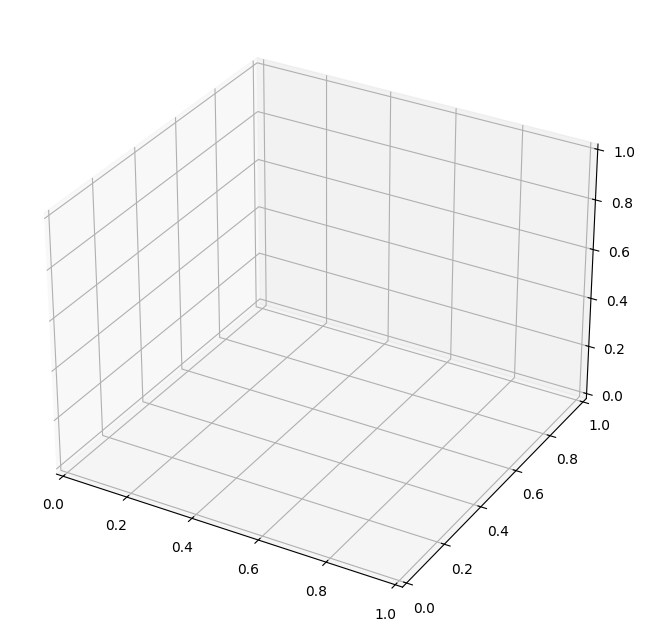

In [8]:
from IPython.display import HTML
surface_animation = animate_adaptive_surface(d=3, sigma=0.45)
HTML(surface_animation.to_jshtml())

## Toric-code lattice and logical-loop animation

Unlike the planar surface-code picture above, this lattice has **periodic boundaries**: the curved links identify the left/right and top/bottom edges. Qubits live on edges, while X (star) and Z (plaquette) stabilisers live on vertices and faces.

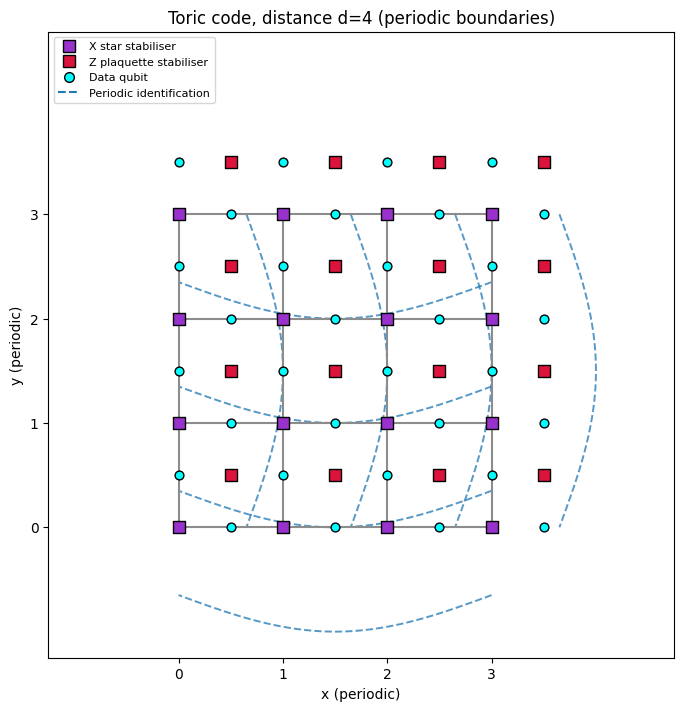

(<Figure size 700x700 with 1 Axes>,
 <Axes: title={'center': 'Toric code, distance d=4 (periodic boundaries)'}, xlabel='x (periodic)', ylabel='y (periodic)'>)

In [12]:
from matplotlib.lines import Line2D

def build_toric_lattice(d):
    """Return a d x d toric-code fundamental domain (2*d**2 qubits)."""
    if d < 2:
        raise ValueError("d must be at least 2")

    stars = [(x, y) for x in range(d) for y in range(d)]
    plaquettes = [(x + 0.5, y + 0.5) for x in range(d) for y in range(d)]
    horizontal_qubits = [(x + 0.5, y) for x in range(d) for y in range(d)]
    vertical_qubits = [(x, y + 0.5) for x in range(d) for y in range(d)]
    return stars, plaquettes, horizontal_qubits, vertical_qubits

def _draw_toric_base(ax, d):
    stars, plaquettes, horizontal, vertical = build_toric_lattice(d)

    # Ordinary links inside the displayed fundamental domain.
    for y in range(d):
        for x in range(d - 1):
            ax.plot([x, x + 1], [y, y], color='0.55', lw=1.5, zorder=1)
    for x in range(d):
        for y in range(d - 1):
            ax.plot([x, x], [y, y + 1], color='0.55', lw=1.5, zorder=1)

    # Curved links make the two periodic boundary identifications visible.
    u = np.linspace(0, 1, 50)
    for y in range(d):
        ax.plot((d - 1) * (1 - u), y - 0.65 - 0.35 * np.sin(np.pi * u),
                color='tab:blue', lw=1.4, ls='--', alpha=0.75, zorder=0)
    for x in range(d):
        ax.plot(x + 0.65 + 0.35 * np.sin(np.pi * u), (d - 1) * (1 - u),
                color='tab:blue', lw=1.4, ls='--', alpha=0.75, zorder=0)

    sx, sy = zip(*stars)
    px, py = zip(*plaquettes)
    qx, qy = zip(*(horizontal + vertical))
    ax.scatter(sx, sy, c='darkorchid', marker='s', s=85, edgecolors='black', zorder=4)
    ax.scatter(px, py, c='crimson', marker='s', s=70, edgecolors='black', zorder=3)
    ax.scatter(qx, qy, c='#5F9EA0', marker='o', s=40, edgecolors='black', zorder=5)
    ax.set(xlim=(-1.25, d + 0.75), ylim=(-1.25, d + 0.75), aspect='equal',
           xlabel='x (periodic)', ylabel='y (periodic)')
    ax.set_xticks(range(d)); ax.set_yticks(range(d))
    ax.grid(False)

def plot_toric_code(d=4):
    """Draw the toric-code graph as a flat periodic fundamental domain."""
    fig, ax = plt.subplots(figsize=(7, 7), layout='constrained')
    _draw_toric_base(ax, d)
    ax.set_title(f'Toric code, distance d={d} (periodic boundaries)')
    handles = [
        Line2D([], [], marker='s', color='none', markerfacecolor='darkorchid', markeredgecolor='black', markersize=9, label='X star stabiliser'),
        Line2D([], [], marker='s', color='none', markerfacecolor='crimson', markeredgecolor='black', markersize=8, label='Z plaquette stabiliser'),
        Line2D([], [], marker='o', color='none', markerfacecolor='#5F9EA0', markeredgecolor='black', markersize=7, label='Data qubit'),
        Line2D([], [], color='tab:blue', ls='--', label='Periodic identification')
    ]
    ax.legend(handles=handles, loc='upper left', fontsize=8)
    plt.show()
    return fig, ax

plot_toric_code(d=4)


In [13]:
from IPython.display import HTML

def build_toric_spacetime(d, T, sigma=0.45, seed=7):
    """Build T periodic toric-code layers and measurements between layers."""
    if T < 2:
        raise ValueError("T must be at least 2")
    rng = np.random.default_rng(seed)
    threshold = np.sqrt(np.pi) / 2
    stars, plaquettes, qubits, spatial_edges = [], [], [], []
    trusted, failed = [], []

    for t in range(T):
        for x in range(d):
            for y in range(d):
                stars.append((x, y, t))
                plaquettes.append((x + 0.5, y + 0.5, t))
                qubits.extend([(x + 0.5, y, t), (x, y + 0.5, t)])
                if x < d - 1:
                    spatial_edges.append(((x, y, t), (x + 1, y, t)))
                if y < d - 1:
                    spatial_edges.append(((x, y, t), (x, y + 1, t)))

        # Syndrome measurements lie halfway between consecutive rounds.
        if t < T - 1:
            for x in range(d):
                for y in range(d):
                    for mx, my in ((x, y), (x + 0.5, y + 0.5)):
                        point = (mx, my, t + 0.5)
                        (failed if abs(rng.normal(0, sigma)) > threshold else trusted).append(point)

    return stars, plaquettes, qubits, trusted, failed, spatial_edges

def animate_toric_spacetime(d=3, T=4, sigma=0.45, interval=700, seed=7):
    """Animate a periodic toric lattice growing along the time axis."""
    stars, plaquettes, qubits, trusted, failed, edges = build_toric_spacetime(d, T, sigma, seed)
    fig = plt.figure(figsize=(9, 8), layout='constrained')
    ax = fig.add_subplot(111, projection='3d')

    def scatter_points(points, **kwargs):
        if points:
            x, y, z = zip(*points)
            ax.scatter(x, y, z, **kwargs)

    def update(frame):
        ax.clear()
        current_t = frame / 2
        shown_stars = [p for p in stars if p[2] <= current_t]
        shown_plaquettes = [p for p in plaquettes if p[2] <= current_t]
        shown_qubits = [p for p in qubits if p[2] <= current_t]
        shown_trusted = [p for p in trusted if p[2] <= current_t]
        shown_failed = [p for p in failed if p[2] <= current_t]

        for p1, p2 in edges:
            if p1[2] <= current_t:
                ax.plot([p1[0], p2[0]], [p1[1], p2[1]], [p1[2], p2[2]], c='0.45', lw=1, alpha=0.35)

        # Dashed arcs show left-right and top-bottom periodic identification.
        u = np.linspace(0, 1, 35)
        for t in range(min(int(current_t), T - 1) + 1):
            for y in range(d):
                ax.plot((d - 1) * (1 - u), y - 0.55 - 0.25 * np.sin(np.pi * u),
                        np.full_like(u, t), c='tab:blue', ls='--', lw=1, alpha=0.45)
            for x in range(d):
                ax.plot(x + 0.55 + 0.25 * np.sin(np.pi * u), (d - 1) * (1 - u),
                        np.full_like(u, t), c='tab:blue', ls='--', lw=1, alpha=0.45)

        # Vertical detector world-lines connect stabilisers through time.
        for x, y in {(p[0], p[1]) for p in shown_stars + shown_plaquettes}:
            ax.plot([x, x], [y, y], [0, min(current_t, T - 1)], c='gray', ls=':', alpha=0.3)

        scatter_points(shown_stars, c='darkorchid', marker='s', s=65, edgecolors='black', alpha=0.55, label='X star')
        scatter_points(shown_plaquettes, c='crimson', marker='s', s=65, edgecolors='black', alpha=0.55, label='Z plaquette')
        scatter_points(shown_qubits, c='#5F9EA0', marker='o', s=24, edgecolors='black', alpha=0.5, label='Data qubit')
        scatter_points(shown_trusted, c='forestgreen', marker='o', s=55, edgecolors='black', label='Trusted measurement')
        scatter_points(shown_failed, c='red', marker='X', s=90, edgecolors='black', label='Untrusted GKP measurement')

        ax.set(xlim=(-1, d), ylim=(-1, d), zlim=(-0.1, T - 0.9),
               xlabel='Periodic x', ylabel='Periodic y', zlabel='Time (measurement rounds)')
        ax.set_zticks(range(T))
        ax.set_title(f'GKP toric-code spacetime | d={d}, sigma={sigma}, t={current_t:g}')
        ax.view_init(elev=24, azim=32)
        ax.legend(loc='upper left', bbox_to_anchor=(1.0, 0.95), fontsize=8)

    animation = FuncAnimation(fig, update, frames=2 * T - 1, interval=interval, repeat=True, blit=False)
    plt.close(fig)
    return animation

# The display call is in the next cell, which uses the flat fundamental-domain view.


In [14]:
def build_flat_toric_spacetime(d, T, sigma=0.45, seed=7):
    """Flat toric layers with duplicated top/right boundary qubits."""
    if d < 2 or T < 2:
        raise ValueError("d and T must both be at least 2")
    rng = np.random.default_rng(seed)
    threshold = np.sqrt(np.pi) / 2
    stars, plaquettes, qubits, ghost_qubits = [], [], [], []
    trusted, failed = [], []

    for t in range(T):
        for x in range(d):
            for z in range(d):
                # Coordinates are (spatial x, time y, spatial z).
                stars.append((x, t, z))
                plaquettes.append((x + 0.5, t, z + 0.5))
                qubits.extend([(x + 0.5, t, z), (x, t, z + 0.5)])

        # These are copies of the opposite boundary qubits, not extra qubits.
        ghost_qubits.extend((d, t, z + 0.5) for z in range(d))       # copy of x=0 edge
        ghost_qubits.extend((x + 0.5, t, d) for x in range(d))       # copy of z=0 edge

        if t < T - 1:
            for x in range(d):
                for z in range(d):
                    for mx, mz in ((x, z), (x + 0.5, z + 0.5)):
                        point = (mx, t + 0.5, mz)
                        (failed if abs(rng.normal(0, sigma)) > threshold else trusted).append(point)

    return stars, plaquettes, qubits, ghost_qubits, trusted, failed

def animate_flat_toric_spacetime(d=3, T=4, sigma=0.45, interval=700, seed=7):
    """Stack flat toric-code diagrams with time along the Y axis."""
    stars, plaquettes, qubits, ghosts, trusted, failed = build_flat_toric_spacetime(d, T, sigma, seed)
    fig = plt.figure(figsize=(10, 8), layout='constrained')
    ax = fig.add_subplot(111, projection='3d')

    def scatter(points, **kwargs):
        if points:
            x, y, z = zip(*points)
            ax.scatter(x, y, z, **kwargs)

    def update(frame):
        ax.clear()
        current_t = frame / 2
        visible = lambda points: [p for p in points if p[1] <= current_t]
        v_stars, v_plaquettes = visible(stars), visible(plaquettes)
        v_qubits, v_ghosts = visible(qubits), visible(ghosts)
        v_trusted, v_failed = visible(trusted), visible(failed)

        # Each measurement round is a flat x-z lattice at y=t.
        for t in range(min(int(current_t), T - 1) + 1):
            for z in range(d + 1):
                ax.plot([0, d], [t, t], [z, z], c='0.55', lw=1, alpha=0.28)
            for x in range(d + 1):
                ax.plot([x, x], [t, t], [0, d], c='0.55', lw=1, alpha=0.28)

        # Stabiliser world-lines run in the plotted Y (time) direction.
        top = min(current_t, T - 1)
        for x in range(d):
            for z in range(d):
                ax.plot([x, x], [0, top], [z, z], c='gray', ls=':', alpha=0.28)
                ax.plot([x + 0.5, x + 0.5], [0, top], [z + 0.5, z + 0.5], c='gray', ls=':', alpha=0.28)

        scatter(v_stars, c='darkorchid', marker='s', s=65, edgecolors='black', alpha=0.55, label='X star')
        scatter(v_plaquettes, c='crimson', marker='s', s=65, edgecolors='black', alpha=0.55, label='Z plaquette')
        scatter(v_qubits, c='#5F9EA0', marker='o', s=28, edgecolors='black', alpha=0.65, label='Data qubit')
        scatter(v_ghosts, c='lightgray', marker='o', s=34, edgecolors='dimgray', alpha=0.9, label='Opposite-edge copy')
        scatter(v_trusted, c='forestgreen', marker='o', s=58, edgecolors='black', label='Trusted measurement')
        scatter(v_failed, c='red', marker='X', s=90, edgecolors='black', label='Untrusted GKP measurement')

        ax.set_xlim(-0.35, d + 0.35)
        ax.set_ylim(-0.1, T - 0.9)
        ax.set_zlim(-0.35, d + 0.35)
        ax.set_xlabel('Spatial x')
        ax.set_ylabel('Time (measurement rounds)')
        ax.set_zlabel('Spatial z')
        ax.set_yticks(range(T))
        ax.set_title(f'Flat GKP toric-code spacetime | d={d}, sigma={sigma}, t={current_t:g}')
        ax.view_init(elev=22, azim=-58)
        ax.legend(loc='upper left', bbox_to_anchor=(1.02, 0.96), fontsize=8)

    animation = FuncAnimation(fig, update, frames=2 * T - 1, interval=interval, repeat=True, blit=False)
    plt.close(fig)
    return animation

# The next cell displays the corrected version with vertical time.


In [ ]:
def plot_flat_toric_code_2d(d=3):
    """Plot one toric-code layer; grey qubits are periodic copies."""
    fig, ax = plt.subplots(figsize=(7, 7), layout='constrained')

    # Draw the displayed fundamental domain.
    for y in range(d + 1):
        ax.plot([0, d], [y, y], c='0.55', lw=1.2, alpha=0.55, zorder=0)
    for x in range(d + 1):
        ax.plot([x, x], [0, d], c='0.55', lw=1.2, alpha=0.55, zorder=0)

    # Keep the left/top representatives; right/bottom are only grey copies.
    stars = [(x, y) for x in range(d) for y in range(1, d + 1)]
    plaquettes = [(x + 0.5, y + 0.5) for x in range(d) for y in range(d)]
    qubits = ([(x + 0.5, y) for x in range(d) for y in range(1, d + 1)] +
              [(x, y + 0.5) for x in range(d) for y in range(d)])
    ghost_qubits = ([(d, y + 0.5) for y in range(d)] +
                    [(x + 0.5, 0) for x in range(d)])

    sx, sy = zip(*stars); px, py = zip(*plaquettes)
    qx, qy = zip(*qubits); gx, gy = zip(*ghost_qubits)
    ax.scatter(sx, sy, c='darkorchid', marker='s', s=95, edgecolors='black', zorder=4, label='X star')
    ax.scatter(px, py, c='crimson', marker='s', s=80, edgecolors='black', zorder=3, label='Z plaquette')
    ax.scatter(qx, qy, c='#5F9EA0', marker='o', s=48, edgecolors='black', zorder=5, label='Data qubit')
    ax.scatter(gx, gy, c='lightgray', marker='o', s=52, edgecolors='dimgray', zorder=5, label='Opposite-edge copy')

    ax.text(d + 0.08, d / 2, 'copy of left edge', rotation=90, va='center', color='dimgray')
    ax.text(d / 2, -0.18, 'copy of top edge', ha='center', va='top', color='dimgray')
    ax.set(xlim=(-0.35, d + 0.85), ylim=(-0.85, d + 0.35), aspect='equal',
           xlabel='Spatial x', ylabel='Spatial y', title=f'One flat toric-code layer (d={d})')
    ax.set_xticks(range(d + 1)); ax.set_yticks(range(d + 1))
    ax.legend(loc='lower left', fontsize=8)
    plt.show()
    return fig, ax

plot_flat_toric_code_2d(d=3)


In [ ]:
def build_vertical_toric_spacetime(d, T, sigma=0.45, seed=7):
    """Return points as (spatial x, spatial y, vertical time)."""
    if d < 2 or T < 2:
        raise ValueError("d and T must both be at least 2")
    rng = np.random.default_rng(seed)
    threshold = np.sqrt(np.pi) / 2
    stars, plaquettes, qubits = [], [], []
    ghost_qubits = []
    trusted, failed = [], []
    for t in range(T):
        for x in range(d):
            for y in range(d):
                stars.append((x, y + 1, t))
                plaquettes.append((x + 0.5, y + 0.5, t))
                qubits.extend([(x + 0.5, y + 1, t), (x, y + 0.5, t)])
        ghost_qubits.extend((d, y + 0.5, t) for y in range(d))
        ghost_qubits.extend((x + 0.5, 0, t) for x in range(d))
        if t < T - 1:
            for x in range(d):
                for y in range(d):
                    for mx, my in ((x, y + 1), (x + 0.5, y + 0.5)):
                        point = (mx, my, t + 0.5)
                        (failed if abs(rng.normal(0, sigma)) > threshold else trusted).append(point)
    return stars, plaquettes, qubits, ghost_qubits, trusted, failed

def animate_vertical_toric_spacetime(d=3, T=4, sigma=0.45, interval=700, seed=7):
    """Animate flat toric layers with time running vertically up the Z axis."""
    groups = build_vertical_toric_spacetime(d, T, sigma, seed)
    stars, plaquettes, qubits, ghost_qubits, trusted, failed = groups
    fig = plt.figure(figsize=(10, 8), layout='constrained')
    ax = fig.add_subplot(111, projection='3d')

    def scatter(points, **kwargs):
        if points:
            x, y, z = zip(*points); ax.scatter(x, y, z, **kwargs)

    def update(frame):
        ax.clear()
        current_t = frame / 2
        visible = lambda points: [p for p in points if p[2] <= current_t]

        # Horizontal x-y lattice sheets, one per completed round.
        for t in range(min(int(current_t), T - 1) + 1):
            for y in range(d + 1):
                ax.plot([0, d], [y, y], [t, t], c='0.5', lw=1, alpha=0.28)
            for x in range(d + 1):
                ax.plot([x, x], [0, d], [t, t], c='0.5', lw=1, alpha=0.28)

        # Dotted vertical lines make the time direction explicit.
        top = min(current_t, T - 1)
        for x in range(d):
            for y in range(d):
                ax.plot([x, x], [y + 1, y + 1], [0, top], c='gray', ls=':', alpha=0.32)
                ax.plot([x + 0.5, x + 0.5], [y + 0.5, y + 0.5], [0, top], c='gray', ls=':', alpha=0.32)

        scatter(visible(stars), c='darkorchid', marker='s', s=65, edgecolors='black', alpha=0.55, label='X star')
        scatter(visible(plaquettes), c='crimson', marker='s', s=65, edgecolors='black', alpha=0.55, label='Z plaquette')
        scatter(visible(qubits), c='#5F9EA0', marker='o', s=28, edgecolors='black', alpha=0.65, label='Data qubit')
        scatter(visible(ghost_qubits), c='lightgray', marker='o', s=34, edgecolors='dimgray', label='Copied boundary qubit')
        scatter(visible(trusted), c='forestgreen', marker='o', s=58, edgecolors='black', label='Trusted measurement')
        scatter(visible(failed), c='red', marker='X', s=90, edgecolors='black', label='Untrusted GKP measurement')

        ax.set(xlim=(-0.35, d + 0.85), ylim=(-0.85, d + 0.35), zlim=(-0.1, T - 0.9),
               xlabel='Spatial x', ylabel='Spatial y', zlabel='Time (measurement rounds)')
        ax.set_zticks(range(T))
        ax.set_title(f'Flat GKP toric-code spacetime | d={d}, sigma={sigma}, t={current_t:g}')
        ax.view_init(elev=24, azim=32)
        ax.legend(loc='upper left', bbox_to_anchor=(1.02, 0.96), fontsize=8)

    animation = FuncAnimation(fig, update, frames=2 * T - 1, interval=interval, repeat=True, blit=False)
    plt.close(fig)
    return animation

toric_animation = animate_vertical_toric_spacetime(d=3, T=4, sigma=0.45)
HTML(toric_animation.to_jshtml())
